# Hypothesis 1 — fast agents mainly interact with each other

A minimal agent-based model supporting the LaTeX mathematical modelling.

- `n × n` grid with edges, Moore neighbourhood (8 neighbours)
- Two agent types, fast and slow, half each, placed at random. Types never change.
- Each agent holds an label: `F` (fast-origin information) or `S` (slow-origin). Label is binary. Everyone starts with their own type's label.
- Propagation is defined as when an agent takes a turn it offers its label to all 8 neighbours. Each neighbour independently accepts with probability `p`.
- Speed is defined as: Fast agents take a turn every tick. Slow agents take a turn every `rho` ticks, so `rho = ΔT_s / ΔT_f`.
- Adopt-propagate cycle = one successful adoption event (an offer that was accepted). We count them in a 2×2 table by (propagator type, adopter type).



In [1]:
# Import required libraroes
import numpy as np
import matplotlib.pyplot as plt

FAST, SLOW = 0, 1          # agent type (fixed)
F, S = 0, 1                # information label (changes)


# the 8 Moore-neighbourhood offsets (row shift, column shift)
OFFSETS = [(di, dj) for di in (-1, 0, 1) for dj in (-1, 0, 1) if (di, dj) != (0, 0)]

## 1. Build the grid for the 2D Moore neighbourhood sim

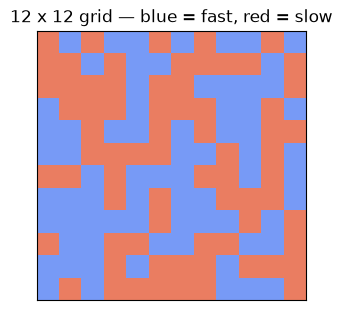

In [ ]:
def make_grid(n, rng):
    """n x n grid, half fast / half slow at random. Everyone starts holding their own type's label."""
    kind = np.full(n * n, SLOW, dtype=int)
    kind[: n * n // 2] = FAST
    rng.shuffle(kind)
    kind = kind.reshape(n, n)
    state = np.where(kind == FAST, F, S)
    return kind, state

rng = np.random.default_rng(0) # seeded random number generator for deterministic outcomes
kind, state = make_grid(12, rng)

#plots
plt.figure(figsize=(3.5, 3.5))
plt.imshow(kind, cmap="coolwarm", vmin=-0.3, vmax=1.3)
plt.title("12 x 12 grid — blue = fast agents (AI), red = slow agents (humans)")
plt.xticks([]); plt.yticks([])
plt.show()

## 2. Neighbours without wrap-around

For an offset `(di, dj)`, `src` selects the agents that offer and `dst` selects the neighbours that receive.


In [3]:
def inside(n, di, dj):
    """Slices so that grid[src] offers to grid[dst] for offset (di, dj), staying inside the n x n grid."""
    r0, r1 = max(0, -di), n - max(0, di)
    c0, c1 = max(0, -dj), n - max(0, dj)
    src = (slice(r0, r1), slice(c0, c1))
    dst = (slice(r0 + di, r1 + di), slice(c0 + dj, c1 + dj))
    return src, dst


## 3. One simulation

Each time tick:
1. work out who is active (fast: always; slow: every `rho` ticks, with a random phase so they don't all fire together)
2. every active agent offers its label to all 8 neighbours; each offer is accepted with probability `p`
3. count each accepted offer
4. adopters copy the propagator's label

Step 4 is what makes it an information-spreading model.

In [5]:
def simulate(n, rho, p, slow_steps, seed=0):
    
    rng = np.random.default_rng(seed) # deterministic outputs from seeded rng
    kind, state = make_grid(n, rng)
    phase = rng.integers(0, rho, size=(n, n))
    events = np.zeros((2, 2), dtype=int)

    for t in range(slow_steps * rho):
        active = (kind == FAST) | ((t + phase) % rho == 0)
        new_state = state.copy()
        for di, dj in OFFSETS:
            src, dst = inside(n, di, dj)
            accepted = active[src] & (rng.random(active[src].shape) < p)
            for a in (FAST, SLOW):
                for b in (FAST, SLOW):
                    events[a, b] += np.count_nonzero(accepted & (kind[src] == a) & (kind[dst] == b))
            target = new_state[dst]                  # a view into new_state
            target[accepted] = state[src][accepted]  # adopter copies the propagator's label
        state = new_state
    return events, kind, state

events, kind, state = simulate(n=40, rho=3, p=0.1, slow_steps=5, seed=1)
print("events[propagator, adopter]  (rows: fast, slow / cols: fast, slow)")
print(events)
print()
print(f"share fast->fast        {events[FAST, FAST] / events.sum():.3f}   predicted {3/(2*4):.3f}")
print(f"share started by fast   {events[FAST].sum() / events.sum():.3f}   predicted {3/4:.3f}")
print(f"share received by fast  {events[:, FAST].sum() / events.sum():.3f}   predicted 0.500")

events[propagator, adopter]  (rows: fast, slow / cols: fast, slow)
[[4576 4514]
 [1583 1489]]

share fast->fast        0.376   predicted 0.375
share started by fast   0.747   predicted 0.750
share received by fast  0.506   predicted 0.500


## 4. The 2×2 table at ρ = 3 against the prediction

The grid above has 800+800 agents and ran for 5 slow steps. Prediction is in the LaTeX doc

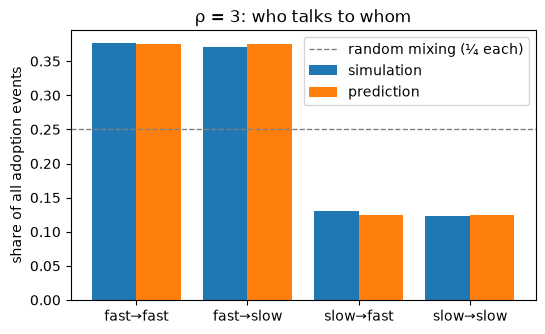

In [6]:
labels = ["fast→fast", "fast→slow", "slow→fast", "slow→slow"]
observed = events.flatten() / events.sum()
predicted3 = np.array([3, 3, 1, 1]) / 8          # 2ρNp : 2ρNp : 2Np : 2Np with ρ = 3

# plots
x = np.arange(4)
plt.figure(figsize=(6, 3.5))
plt.bar(x - 0.2, observed, 0.4, label="simulation")
plt.bar(x + 0.2, predicted3, 0.4, label="prediction")
plt.axhline(0.25, color="grey", linestyle="--", linewidth=1, label="random mixing (¼ each)")
plt.xticks(x, labels)
plt.ylabel("share of all adoption events")
plt.title("ρ = 3: who talks to whom")
plt.legend()
plt.show()

## 5. Sweep the speed ratio ρ ∈ {1, 3, 10, 100}

rho =   1   fast->fast 0.249   started by fast 0.503   received by fast 0.505
rho =   3   fast->fast 0.376   started by fast 0.747   received by fast 0.506
rho =  10   fast->fast 0.454   started by fast 0.908   received by fast 0.501
rho = 100   fast->fast 0.491   started by fast 0.990   received by fast 0.496


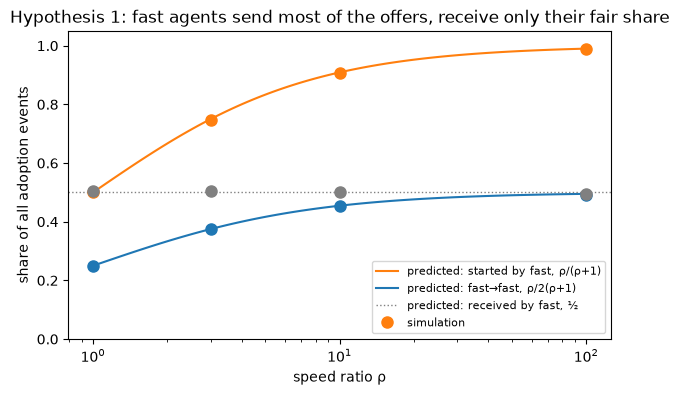

In [8]:
RHOS = [1, 3, 10, 100] # chosen arbitrarily and justified in the blog
ff_share, fast_started, fast_received = [], [], []

for rho in RHOS:
    ev, _, _ = simulate(n=40, rho=rho, p=0.1, slow_steps=5, seed=1)
    tot = ev.sum()
    ff_share.append(ev[FAST, FAST] / tot)
    fast_started.append(ev[FAST].sum() / tot)
    fast_received.append(ev[:, FAST].sum() / tot)
    print(f"rho = {rho:3d}   fast->fast {ff_share[-1]:.3f}   started by fast {fast_started[-1]:.3f}   received by fast {fast_received[-1]:.3f}")
# plots
rho_line = np.logspace(0, 2, 100)
plt.figure(figsize=(7, 4))
plt.plot(rho_line, rho_line / (rho_line + 1), color="C1", label="predicted: started by fast, ρ/(ρ+1)")
plt.plot(rho_line, rho_line / (2 * (rho_line + 1)), color="C0", label="predicted: fast→fast, ρ/2(ρ+1)")
plt.axhline(0.5, color="grey", linestyle=":", linewidth=1, label="predicted: received by fast, ½")
plt.plot(RHOS, fast_started, "o", color="C1", markersize=8, label="simulation")
plt.plot(RHOS, ff_share, "o", color="C0", markersize=8)
plt.plot(RHOS, fast_received, "o", color="grey", markersize=8)
plt.xscale("log")
plt.xlabel("speed ratio ρ")
plt.ylabel("share of all adoption events")
plt.ylim(0, 1.05)
plt.title("Hypothesis 1: fast agents send most of the offers, receive only their fair share")
plt.legend(loc="lower right", fontsize=8)
plt.show()

## 6. Hypothesis 2: fast-origin information drowns out slow-origin information

The blog defines the outcome measure as the share of slow-origin information relative to the share of slow agents using the C-index


In [9]:
def simulate_trace(n, rho, ticks, P, seed):
    
    rng = np.random.default_rng(seed) # deterministic seeded outcome
    kind, state = make_grid(n, rng)
    phase = rng.integers(0, rho, size=(n, n))
    nS = np.empty(ticks + 1, dtype=int)
    nS[0] = np.count_nonzero(state == S)

    for t in range(ticks):
        active = (kind == FAST) | ((t + phase) % rho == 0)
        new_state = state.copy()
        for di, dj in OFFSETS:
            src, dst = inside(n, di, dj)
            prob = P[kind[src], kind[dst]]                # per-pair acceptance probability
            accepted = active[src] & (rng.random(prob.shape) < prob)
            target = new_state[dst]
            target[accepted] = state[src][accepted]
        state = new_state
        nS[t + 1] = np.count_nonzero(state == S)
    return nS


def tau_ticks(rho, p=0.1, k=8, f=0.5):
    """Mixing timescale in units of the fast tick, as in tau"""
    return 1.0 / (k * p * (f + (1 - f) / rho))


N_SIDE, P_SCALAR, SEEDS, T_HORIZON = 40, 0.1, 200, 60
N = N_SIDE ** 2
P_UNIFORM = np.full((2, 2), P_SCALAR)           # P_ff = P_fs = P_sf = P_ss = p
RHOS_C = [1, 2, 3, 5, 10, 30, 100]

print(f"horizon T = {T_HORIZON} ticks, {SEEDS} seeds, {N_SIDE}x{N_SIDE} grid, p = {P_SCALAR}\n")
for rho in RHOS_C:
    print(f"  rho = {rho:3d}   tau = {tau_ticks(rho):.2f} ticks   T/tau = {T_HORIZON / tau_ticks(rho):5.1f}")

horizon T = 60 ticks, 200 seeds, 40x40 grid, p = 0.1

  rho =   1   tau = 1.25 ticks   T/tau =  48.0
  rho =   2   tau = 1.67 ticks   T/tau =  36.0
  rho =   3   tau = 1.88 ticks   T/tau =  32.0
  rho =   5   tau = 2.08 ticks   T/tau =  28.8
  rho =  10   tau = 2.27 ticks   T/tau =  26.4
  rho =  30   tau = 2.42 ticks   T/tau =  24.8
  rho = 100   tau = 2.48 ticks   T/tau =  24.2


### Numerical method proof for the second hypothesis

Run the sweep and look at the fraction of the population holding slow-origin information over time. 

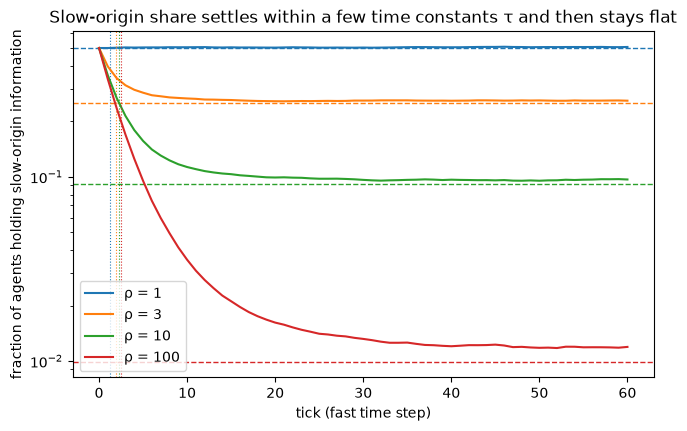

mean slow-origin fraction, showing the plateau is flat:


In [ ]:
traces = {rho: np.array([simulate_trace(N_SIDE, rho, T_HORIZON, P_UNIFORM, seed)
                         for seed in range(SEEDS)])
          for rho in RHOS_C}


# plots
plt.figure(figsize=(7.5, 4.5))
for i, rho in enumerate([1, 3, 10, 100]):
    mean_frac = traces[rho].mean(axis=0) / N
    plt.plot(mean_frac, color=f"C{i}", label=f"ρ = {rho}")
    plt.axhline(1 / (rho + 1), color=f"C{i}", linestyle="--", linewidth=1)
    plt.axvline(tau_ticks(rho), color=f"C{i}", linestyle=":", linewidth=0.8)
plt.yscale("log")
plt.xlabel("tick (fast time step)")
plt.ylabel("fraction of agents holding slow-origin information")
plt.title("Slow-origin share settles within a few time constants τ and then stays flat")
plt.legend()
plt.show()

